In [73]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu May 29 14:27:01 2025

@author: xies
"""

# Core libraries
import numpy as np
# from skimage import io
import pandas as pd
import matplotlib.pylab as plt
from scipy import spatial

# General utils
from tqdm import tqdm
from os import path
# from basicUtils import nonans

dx = 0.25
dz = 1

# Filenames
dirname = '/Users/xies/OneDrive - Stanford/Skin/Mesa et al/W-R1/'
R1 = pd.read_pickle(path.join(dirname,'Mastodon/single_timepoints_dynamics.pkl'))
dirname = '/Users/xies/OneDrive - Stanford/Skin/Mesa et al/W-R2/'
R2 = pd.read_pickle(path.join(dirname,'Mastodon/single_timepoints_dynamics.pkl'))

KS_stat = {}


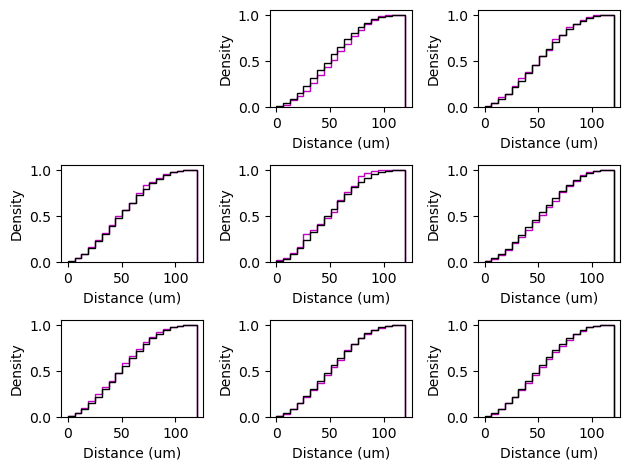

In [103]:
from basicUtils import nonans
from scipy.stats import ks_2samp

for t in range(1,9):
    df = R2.droplevel(axis=1,level=1)
    df_now = df.loc[t,:]
    df_m1 = df.loc[t-1,:]
    
    delam = df_m1[ (df_m1['Delaminate next frame']) & ~(df_m1['Border'])].reset_index()
    distances_delaminating = spatial.distance_matrix(delam[['X','Y']],delam[['X','Y']])
    distances_delaminating[np.eye(len(distances_delaminating)) > 0] = np.nan
    
    divide = df_now[ (df_now['Divide next frame']) & ~(df_now['Border'])].reset_index()
    distances_dividing = spatial.distance_matrix(divide[['X','Y']],divide[['X','Y']])
    distances_dividing[np.eye(len(distances_dividing)) > 0] = np.nan
    
    distances_div_to_delam = spatial.distance_matrix(delam[['X','Y','Z']],divide[['X','Y','Z']])
    
    Niter = 100
    random_distances = []
    for i in range(Niter):
        x = df_now[ (~df_now['Border']) & (df_now['Cell type'] == 'Basal') 
                   ].sample(len(distances_div_to_delam)).reset_index()
        D = spatial.distance_matrix(x[['X','Y','Z']],x[['X','Y','Z']])
        D[np.eye(len(D)) > 0] = np.nan
        random_distances.append(D)
    
    mean_random_distances = np.stack(random_distances).mean(axis=0)
    plt.subplot(3,3,t+1)
    # plt.hist(distances_dividing.flatten(),bins=25,histtype='step',cumulative=True,density=True,color='b')
    # plt.hist(distances_delaminating.flatten(),bins=25,histtype='step',cumulative=True,density=True,color='r')
    bins = np.linspace(0,120,20)
    plt.hist(distances_div_to_delam.flatten(),bins,histtype='step',cumulative=True,density=True,color='m')
    plt.hist(nonans(np.array(random_distances).flatten()),bins,histtype='step',cumulative=True,density=True,color='k')
    
    # plt.legend(['Delaminating','Dividing','Random cells'])
    plt.xlabel('Distance (um)')
    plt.ylabel('Density')

    KS_stat[('R2',t)] = ks_2samp(
        nonans(np.array(random_distances).flatten()),
        nonans(distances_div_to_delam.flatten()),
        alternative='two-sided',
    ).pvalue

plt.tight_layout()


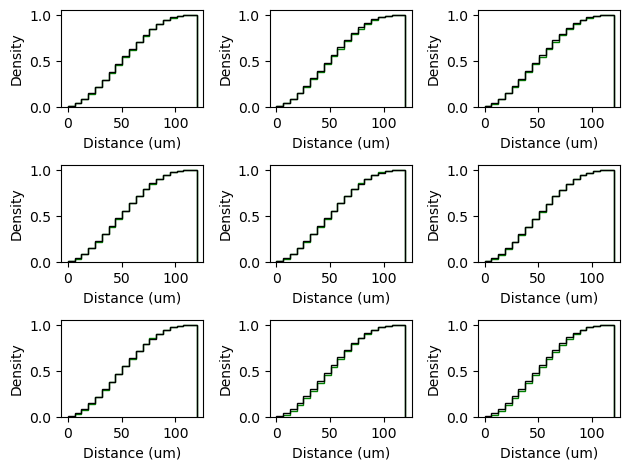

In [113]:
from basicUtils import nonans
from scipy.stats import ks_2samp

for t in range(0,9):
    df = R2.droplevel(axis=1,level=1)
    df_now = df.loc[t,:]
    # df_m1 = df.loc[t-1,:]
    
    delam = df_now[ (df_now['Will differentiate']) & ~(df_now['Border'])].reset_index()
    distances_delaminating = spatial.distance_matrix(delam[['X','Y']],delam[['X','Y']])
    distances_delaminating[np.eye(len(distances_delaminating)) > 0] = np.nan
    
    divide = df_now[ (df_now['Will divide']) & ~(df_now['Border'])].reset_index()
    distances_dividing = spatial.distance_matrix(divide[['X','Y']],divide[['X','Y']])
    distances_dividing[np.eye(len(distances_dividing)) > 0] = np.nan
    
    distances_div_to_delam = spatial.distance_matrix(delam[['X','Y','Z']],divide[['X','Y','Z']])
    
    Niter = 100
    random_distances = []
    for i in range(Niter):
        x = df_now[ (~df_now['Border']) & (df_now['Cell type'] == 'Basal') 
                   ].sample(100).reset_index()
        D = spatial.distance_matrix(x[['X','Y','Z']],x[['X','Y','Z']])
        D[np.eye(len(D)) > 0] = np.nan
        random_distances.append(D)
    
    mean_random_distances = np.stack(random_distances).mean(axis=0)
    plt.subplot(3,3,t+1)
    # plt.hist(distances_dividing.flatten(),bins=25,histtype='step',cumulative=True,density=True,color='b')
    # plt.hist(distances_delaminating.flatten(),bins=25,histtype='step',cumulative=True,density=True,color='r')
    bins = np.linspace(0,120,20)
    plt.hist(distances_div_to_delam.flatten(),bins,histtype='step',cumulative=True,density=True,color='g')
    plt.hist(nonans(np.array(random_distances).flatten()),bins,histtype='step',cumulative=True,density=True,color='k')
    
    # plt.legend(['Delaminating','Dividing','Random cells'])
    plt.xlabel('Distance (um)')
    plt.ylabel('Density')

    KS_stat[('R2',t)] = ks_2samp(
        nonans(np.array(random_distances).flatten()),
        nonans(distances_div_to_delam.flatten()),
        alternative='two-sided',
    ).pvalue

plt.tight_layout()


In [92]:
KS_stat

{('R2', 0): np.float64(9.502808986236022e-08),
 ('R2', 1): np.float64(0.006933668906935878),
 ('R2', 2): np.float64(0.9526601493637066),
 ('R2', 3): np.float64(0.4318063689203667),
 ('R2', 4): np.float64(0.1942091497913),
 ('R2', 5): np.float64(0.017503114646457922),
 ('R2', 6): np.float64(0.01677266010781803),
 ('R2', 7): np.float64(0.08186353966249116),
 ('R2', 8): np.float64(0.3492744113421037),
 ('R1', 0): np.float64(0.1374068957678547),
 ('R1', 1): np.float64(0.0009980784580313235),
 ('R1', 2): np.float64(0.009406753928693204),
 ('R1', 3): np.float64(0.4674179077695494),
 ('R1', 4): np.float64(1.0438606278179343e-10),
 ('R1', 5): np.float64(0.06480655474037655),
 ('R1', 6): np.float64(0.3963586959489047),
 ('R1', 7): np.float64(0.44040149576348875),
 ('R1', 8): np.float64(2.485868251969421e-10)}

array([51.74643754, 65.22869837, 51.59224744, ..., 51.62126367,
        6.83953722, 57.14752029])

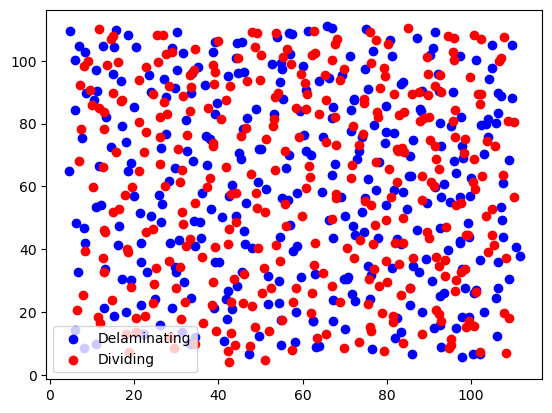

In [4]:


#%%

plt.scatter(delam['X'],delam['Y'],color='b')
plt.scatter(divide['X'],divide['Y'],color='r')
plt.legend(['Delaminating','Dividing'])


